In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("./files/prj_data_eda.csv")
df.head()

,고객ID,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,성별_남,성별_여,거주지역_경기,...,거주지역_대구,거주지역_부산,거주지역_서울,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y,평균구매단가
0,C0001,-1.473866,1,-0.498053,-0.183592,-0.805421,1,True,False,False,...,True,False,False,False,True,False,False,True,False,-0.471432
1,C0002,1.031289,3,2.018989,2.273239,1.787932,0,False,True,False,...,False,True,False,False,False,True,False,False,True,-0.348047
2,C0003,0.613763,0,-1.182477,-1.076986,-0.805421,0,False,True,False,...,False,False,False,False,True,False,False,False,True,-0.332295
3,C0004,-0.221289,1,-0.309411,-1.076986,0.120776,0,False,True,True,...,False,False,False,False,True,False,False,True,False,1.211928
4,C0005,-0.221289,2,0.465858,-0.183592,2.158411,0,True,False,True,...,False,False,False,False,False,True,False,True,False,0.259242


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   고객ID       500 non-null    str    
 1   나이         500 non-null    float64
 2   멤버십등급      500 non-null    int64  
 3   월평균구매금액    500 non-null    float64
 4   구매횟수       500 non-null    float64
 5   리뷰점수       500 non-null    float64
 6   이탈여부       500 non-null    int64  
 7   성별_남       500 non-null    bool   
 8   성별_여       500 non-null    bool   
 9   거주지역_경기    500 non-null    bool   
 10  거주지역_기타    500 non-null    bool   
 11  거주지역_대구    500 non-null    bool   
 12  거주지역_부산    500 non-null    bool   
 13  거주지역_서울    500 non-null    bool   
 14  가입경로_광고    500 non-null    bool   
 15  가입경로_앱     500 non-null    bool   
 16  가입경로_웹     500 non-null    bool   
 17  가입경로_지인추천  500 non-null    bool   
 18  쿠폰사용여부_N   500 non-null    bool   
 19  쿠폰사용여부_Y   500 non-null    bool   
 20  평균구매단가     500 non-nu

In [3]:
df.shape

(500, 21)

In [4]:
df.dtypes

고객ID             str
나이           float64
멤버십등급          int64
월평균구매금액      float64
구매횟수         float64
리뷰점수         float64
이탈여부           int64
성별_남            bool
성별_여            bool
거주지역_경기         bool
거주지역_기타         bool
거주지역_대구         bool
거주지역_부산         bool
거주지역_서울         bool
가입경로_광고         bool
가입경로_앱          bool
가입경로_웹          bool
가입경로_지인추천       bool
쿠폰사용여부_N        bool
쿠폰사용여부_Y        bool
평균구매단가       float64
dtype: object

In [5]:
df.describe()

,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,평균구매단가
count,5.000000e+02,500.000000,5.000000e+02,5.000000e+02,5.000000e+02,500.000000,5.000000e+02
mean,1.065814e-17,1.058000,8.881784e-17,-2.131628e-17,-6.377121e-16,0.380000,1.154632e-16
std,1.001002e+00,1.022118,1.001002e+00,1.001002e+00,1.001002e+00,0.485873,1.001002e+00
min,-1.752216e+00,0.000000,-1.426102e+00,-1.523682e+00,-2.287338e+00,0.000000,-1.174920e+00
25%,-7.779896e-01,0.000000,-8.035115e-01,-8.536373e-01,-6.201819e-01,0.000000,-4.901749e-01
50%,-1.252577e-02,1.000000,-2.411195e-01,-1.835923e-01,-6.446335e-02,0.000000,-2.571468e-01
75%,8.921133e-01,2.000000,6.060669e-01,5.422898e-01,6.764947e-01,1.000000,8.219864e-02
max,1.796752e+00,3.000000,2.720435e+00,2.943284e+00,2.343650e+00,1.000000,6.570926e+00


In [6]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()

print("수치형 컬럼:", num_cols)
print("범주형 컬럼:", cat_cols)

수치형 컬럼: ['나이', '멤버십등급', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부', '평균구매단가']
범주형 컬럼: ['고객ID', '성별_남', '성별_여', '거주지역_경기', '거주지역_기타', '거주지역_대구', '거주지역_부산', '거주지역_서울', '가입경로_광고', '가입경로_앱', '가입경로_웹', '가입경로_지인추천', '쿠폰사용여부_N', '쿠폰사용여부_Y']


In [7]:
df["성별_남"].value_counts(), df["성별_여"].value_counts()

(성별_남
 False    270
 True     230
 Name: count, dtype: int64,
 성별_여
 True     270
 False    230
 Name: count, dtype: int64)

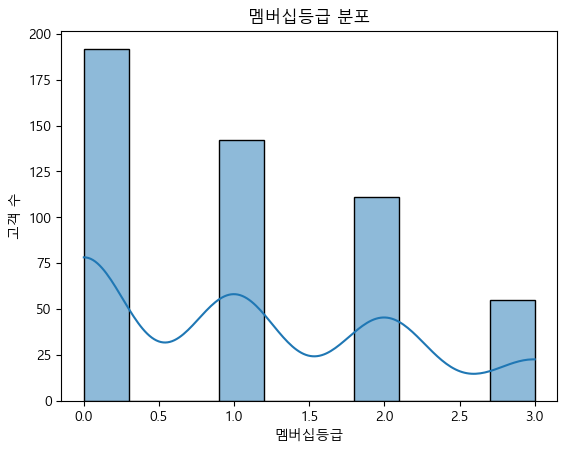

In [8]:
# 멤버십등급 {0:브론즈, 1:실버, 2:골드, 3:VIP}

sns.histplot(df["멤버십등급"], kde=True)
plt.title("멤버십등급 분포")
plt.xlabel("멤버십등급")
plt.ylabel("고객 수")
plt.show()

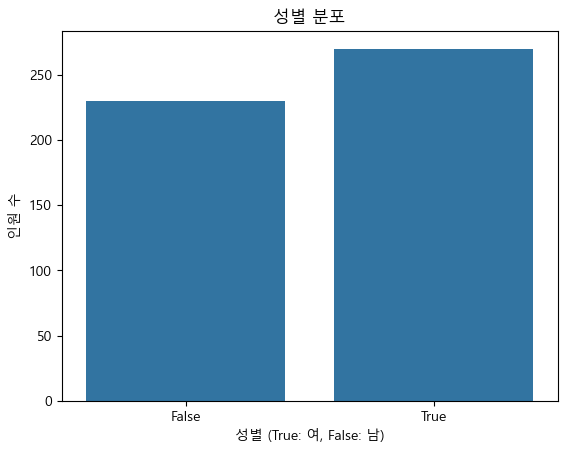

In [9]:
sns.countplot(x=df["성별_여"])
plt.title("성별 분포")
plt.xlabel("성별 (True: 여, False: 남)")
plt.ylabel("인원 수")
plt.show()

In [10]:
df["멤버십등급"].skew()

np.float64(0.5053409278189445)

In [11]:
df["멤버십등급"].value_counts().sort_index()

멤버십등급
0    192
1    142
2    111
3     55
Name: count, dtype: int64

- 멤버십등급 분포는 브론즈 등급에 고객이 가장 많이 몰려 있고(192명), 등급이 높아질수록(실버 142명 → 골드 111명 → VIP 55명)  
  고객 수가 점차 감소하는 형태를 보이며, 왜도는 약 0.51로 양의 값을 나타내어 낮은 등급 쪽으로 치우친 분포임을 수치로도 확인할 수 있다.
- 특히 골드에서 VIP로 갈 때 고객 수가 약 50% 감소하여, 다른 구간(20%대 감소)에 비해 가장 큰 폭으로 줄어드는 특이 구간으로 나타난다.

In [12]:
corr_matrix = df[num_cols].corr()
corr_matrix

,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,평균구매단가
나이,1.000000,-0.016113,0.028737,0.018682,0.023349,-0.035899,0.007751
멤버십등급,-0.016113,1.000000,0.852560,0.883319,0.702396,-0.375364,-0.201231
월평균구매금액,0.028737,0.852560,1.000000,0.773339,0.590962,-0.312676,0.087640
구매횟수,0.018682,0.883319,0.773339,1.000000,0.626467,-0.336072,-0.419192
리뷰점수,0.023349,0.702396,0.590962,0.626467,1.000000,-0.303872,-0.151194
이탈여부,-0.035899,-0.375364,-0.312676,-0.336072,-0.303872,1.000000,0.090072
평균구매단가,0.007751,-0.201231,0.087640,-0.419192,-0.151194,0.090072,1.000000


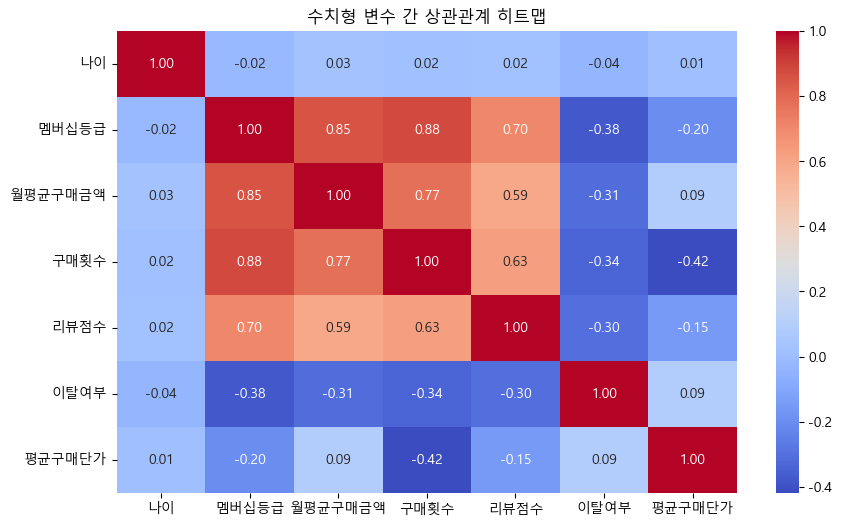

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("수치형 변수 간 상관관계 히트맵")
plt.show()

In [14]:
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs != 1.0]
corr_pairs.sort_values(ascending=False).head(5)

멤버십등급    구매횟수       0.883319
구매횟수     멤버십등급      0.883319
월평균구매금액  멤버십등급      0.852560
멤버십등급    월평균구매금액    0.852560
월평균구매금액  구매횟수       0.773339
dtype: float64

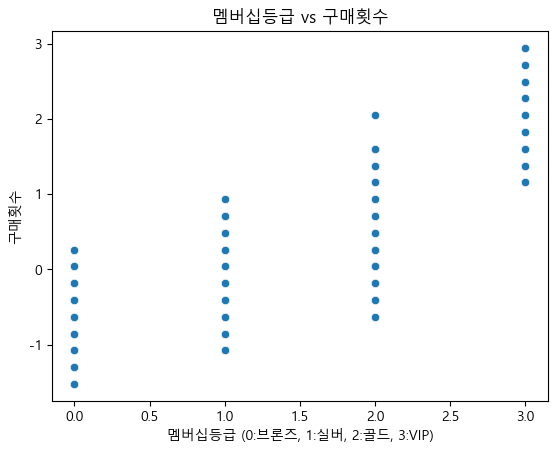

In [15]:
sns.scatterplot(x=df["멤버십등급"], y=df["구매횟수"])
plt.title("멤버십등급 vs 구매횟수")
plt.xlabel("멤버십등급 (0:브론즈, 1:실버, 2:골드, 3:VIP)")
plt.ylabel("구매횟수")
plt.show()

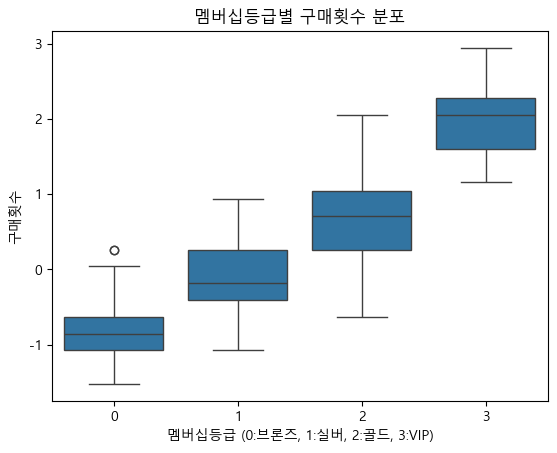

In [16]:
sns.boxplot(x=df["멤버십등급"], y=df["구매횟수"])
plt.title("멤버십등급별 구매횟수 분포")
plt.xlabel("멤버십등급 (0:브론즈, 1:실버, 2:골드, 3:VIP)")
plt.ylabel("구매횟수")
plt.show()

- 멤버십등급과 구매횟수는 상관계수 0.88로 양의 상관관계를 보이며, scatterplot과 boxplot 모두에서 등급이 높아질수록 구매횟수의 중앙값과 분포 전체가 꾸준히 상승하는 패턴이 뚜렷하게 나타난다.
- 특히 브론즈와 VIP 등급 간에는 구매횟수 분포가 거의 겹치지 않을 정도로 뚜렷한 차이를 보인다.

In [17]:
gender_cols = ["성별_남", "성별_여"]
target_cols = ['나이', '멤버십등급', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부', '평균구매단가']

gender_stats = pd.DataFrame({
    gender: df.groupby(gender)[target_cols].mean().loc[True]
    for gender in gender_cols
}).T

gender_stats

,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,평균구매단가
성별_남,0.005325,1.047826,-0.016804,0.006739,-0.008891,0.360870,0.028894
성별_여,-0.004536,1.066667,0.014314,-0.005741,0.007574,0.396296,-0.024614


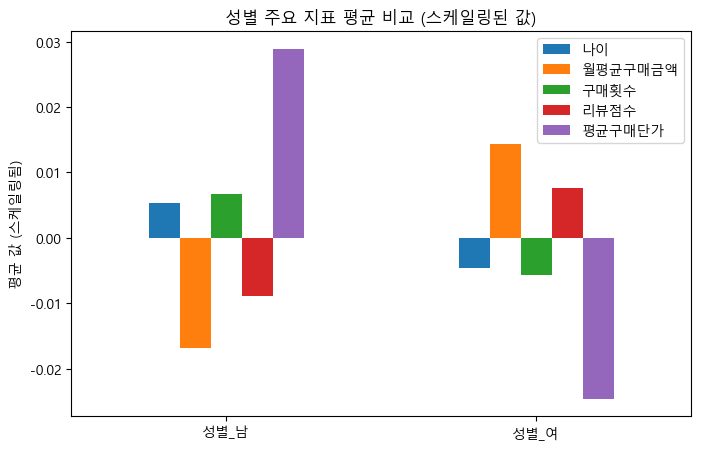

In [18]:
scaled_cols = ["나이", "월평균구매금액", "구매횟수", "리뷰점수", "평균구매단가"]
gender_stats[scaled_cols].plot(kind="bar", figsize=(8,5))
plt.title("성별 주요 지표 평균 비교 (스케일링된 값)")
plt.ylabel("평균 값 (스케일링됨)")
plt.xticks(rotation=0)
plt.show()

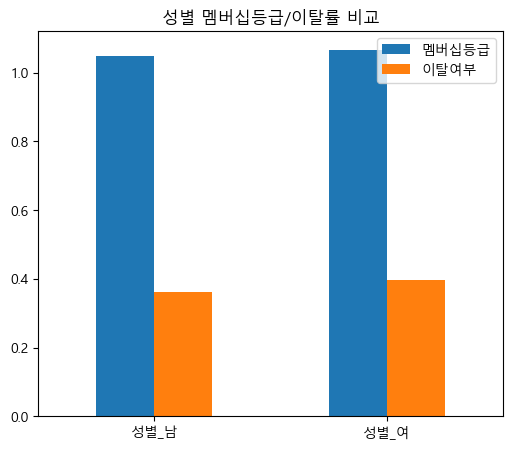

In [19]:
other_cols = ["멤버십등급", "이탈여부"]
gender_stats[other_cols].plot(kind="bar", figsize=(6,5))
plt.title("성별 멤버십등급/이탈률 비교")
plt.xticks(rotation=0)
plt.show()

- 나이, 월평균구매금액, 구매횟수, 리뷰점수, 평균구매단가 등 스케일링된 5개 지표는 y축 범위가 -0.03~0.03에 불과할 정도로 남녀 간 차이가 매우 작다.  
멤버십등급 역시 남(1.05)과 여(1.07)로 거의 동일하여, 성별은 고객의 구매 성향이나 등급을 구분하는 유의미한 요인이 아니라고 판단된다.
- 이탈률은 남성 36.1%, 여성 39.6%로 다소 차이가 있으나 3.5% 정도에 그치며, 나머지 6개 지표 모두 차이가 거의 없는 점을 고려하면 실질적인 의미를 부여하기는 어렵다.